# Data
### Obesity Levels Dataset: Feature Reference

#### Numerical Features
These represent continuous measurements, daily habits, or frequencies:
* **`Age`**: Age of the individual in years.
* **`Height`**: Height of the individual in meters.
* **`Weight`**: Weight of the individual in kilograms.
* **`FCVC`** *(Frequency of Consumption of Vegetables)*: How often the individual eats vegetables with meals (scaled from 1 to 3).
* **`NCP`** *(Number of Main Meals)*: Typical number of main meals eaten per day (between 1 and 4).
* **`CH2O`** *(Consumption of Water)*: Daily water intake in liters (scaled from 1 to 3).
* **`FAF`** *(Physical Activity Frequency)*: Weekly frequency of physical activity (scaled from 0 to 3, where 0 is none and 3 is high).
* **`TUE`** *(Time Using Technology Devices)*: Daily time spent using technological devices like cell phones, computers, or television (scaled from 0 to 2).

---

#### Binary Features
These are simple `0` or `1` (No/Yes) indicators representing demographics, habits, and transportation:
* **`Gender_Male`**: `1` if Male, `0` if Female.
* **`family_history_with_overweight_yes`**: `1` if the individual has family members who suffer or have suffered from being overweight.
* **`FAVC_yes`**: `1` if the individual frequently consumes high-caloric food (Fast Food).
* **`SMOKE_yes`**: `1` if the individual smokes cigarettes.
* **`SCC_yes`**: `1` if the individual monitors their daily calorie intake.
* **`Automobile` / `Bike` / `Motorbike` / `Public_Transportation` / `Walking`**: One-hot encoded group indicating the primary mode of transportation used daily.

---

#### Ordinal Features
Features with an inherent, progressive order (e.g., frequency scales):
* **`CAEC`** *(Consumption of Food Between Meals)*: Tracks snacking frequency. Values range across *No, Sometimes, Frequently, Always*.
* **`CALC`** *(Consumption of Alcohol)*: Tracks how often alcohol is consumed. Values range across *No, Sometimes, Frequently, Always*.

### ⚠️ Data Disclosure: Synthetic Instances (SMOTE)
Please note that this dataset contains synthetic rows generated via **SMOTE** (Synthetic Minority Over-sampling Technique) to balance the target classes.

As a result, several naturally discrete or integer habits—such as **`FCVC`** (vegetable consumption), **`NCP`** (number of meals), **`CH2O`** (water intake), **`FAF`** (physical activity), and **`TUE`** (tech use)—appear as continuous floating-point decimals (e.g., `1.39`, `2.74`). These fractional values represent a sliding frequency scale and have been preserved intentionally to provide smoother decision boundaries for machine learning estimators and richer gradient curves in our XAI (SHAP/LIME) evaluations.

In [16]:
import pandas as pd
import os

from sympy import true

path = os.path.join('Data', 'data.csv')
data = pd.read_csv(path, index_col=0)

X, y = data.iloc[:, :-1], data.iloc[:, -1]

X

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,CAEC,CALC,Automobile,Bike,Motorbike,Public_Transportation,Walking,Gender_Male,family_history_with_overweight_yes,FAVC_yes,SMOKE_yes,SCC_yes
0,24.443011,1.699998,81.669950,2.000000,2.983297,2.763573,0.000000,0.976473,1,1,0,0,0,1,0,1,1,1,0,0
1,18.000000,1.560000,57.000000,2.000000,3.000000,2.000000,1.000000,1.000000,2,0,1,0,0,0,0,0,1,1,0,0
2,18.000000,1.711460,50.165754,1.880534,1.411685,1.910378,0.866045,1.673584,1,0,0,0,0,1,0,0,1,1,0,0
3,20.952737,1.710730,131.274851,3.000000,3.000000,1.674061,1.467863,0.780199,1,1,0,0,0,1,0,0,1,1,0,0
4,31.641081,1.914186,93.798055,2.679664,1.971472,1.979848,1.967973,0.931721,1,1,0,0,0,1,0,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20753,25.137087,1.766626,114.187096,2.919584,3.000000,2.151809,1.330519,0.196680,1,1,0,0,0,1,0,1,1,1,0,0
20754,18.000000,1.710000,50.000000,3.000000,4.000000,1.000000,2.000000,1.000000,2,1,0,0,0,1,0,1,0,1,0,0
20755,20.101026,1.819557,105.580491,2.407817,3.000000,2.000000,1.158040,1.198439,1,0,0,0,0,1,0,1,1,1,0,0
20756,33.852953,1.700000,83.520113,2.671238,1.971472,2.144838,0.000000,0.973834,1,0,1,0,0,0,0,1,1,1,0,0


## Data Split

In [15]:
from sklearn.model_selection import train_test_split

X_trainval, X_test,y_trainval , y_test = train_test_split(X, y,stratify=y, test_size=0.2, random_state=42)

print(f'train-val instances: {len(y_trainval)}\n'
      f'test-val instances: {len(y_test)}')

train-val instances: 16606
test-val instances: 4152


# EDA - Exploratory Data Analysis

In [36]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import numpy as np

# This splits off exactly 5,000 rows for EDA
_, X_sample, _ , y_sample  = train_test_split(
    X_trainval, y_trainval,
    test_size=5000,
    stratify=y_trainval,
    random_state=42
)

print(f"Original shape: {X_trainval.shape}")
print(f"EDA Sample shape: {X_sample.shape}")
print(y_sample.value_counts()) # Verify it's still perfectly balanced

Original shape: (16606, 20)
EDA Sample shape: (5000, 20)
NObeyesdad
6    975
5    782
1    742
4    701
0    608
3    607
2    585
Name: count, dtype: int64


### EDA Functions

In [39]:
# Numerical
def check_normality(data, label="Dataset"):
    """
    Performs K-S test for normality and visualizes the distribution.
    """
    # 1. Calculate parameters for the comparison distribution
    mu = np.mean(data)
    std = np.std(data, ddof=1)

    # 2. Perform Kolmogorov-Smirnov Test
    # We compare the data to a normal distribution with the sample's mean and std
    statistic, p_value = stats.kstest(data, 'norm', args=(mu, std))

    # 3. Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram with KDE
    sns.histplot(data, kde=True, ax=axes[0], color='royalblue', stat="density")
    axes[0].set_title(f'Histogram & KDE: {label}')

    # Probability Plot (Q-Q Plot)
    stats.probplot(data, dist="norm", plot=axes[1])
    axes[1].get_lines()[0].set_markerfacecolor('royalblue')
    axes[1].set_title(f'Probability Plot: {label}')

    plt.tight_layout()
    plt.show()

    # Output results
    print(f"--- Normality Test Results: {label} ---")
    print(f"K-S Statistic: {statistic:.4f}")
    print(f"P-value:       {p_value:.4f}")

    if p_value > 0.05:
        print("Result: Fail to reject the null hypothesis (Data looks normal).")
    else:
        print("Result: Reject the null hypothesis (Data does NOT look normal).")

def plot_correlation_heatmap(df, title="Correlation Heatmap", size=(12, 10)):
    """
    Calculates Pearson correlation for numerical features and plots a heatmap.

    Parameters:
    df (pd.DataFrame): The input dataframe.
    title (str): The title of the plot.
    size (tuple): The figure size (width, height).
    """
    # 1. Select only numerical columns and calculate Pearson correlation
    corr_matrix = df.select_dtypes(include=['number']).corr(method='pearson')

    # 2. Set up the matplotlib figure
    plt.figure(figsize=size)

    # 3. Create the heatmap
    # annot=True: Adds the numerical values
    # cmap='coolwarm': High contrast for positive/negative correlations
    # fmt=".2f": Rounds annotations to 2 decimal places
    heatmap = sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        linewidths=0.5,
        square=True,
        cbar_kws={"shrink": .8}
    )

    plt.title(title, fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.show()

## Target

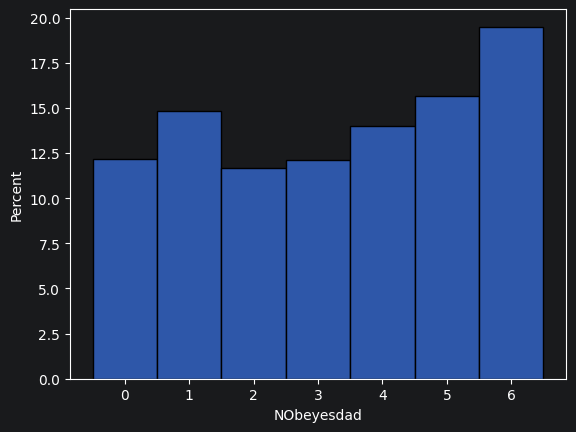

In [35]:
sns.histplot(data=y_sample, discrete=True, stat="percent")
plt.show()

## Continuous Numerical Features
(Age, Height, Weight)

### Additional BMI feat - domian knowladge
The entire purpose of the BMI formula ($BMI = \frac{\text{Weight}}{\text{Height}^2}$) was mathematically engineered by statisticians to cancel out the effect of height on body mass.

In [52]:
X_sample['BMI'] = X_sample['Weight'] / (X_sample['Height']**2)

### Normality Check

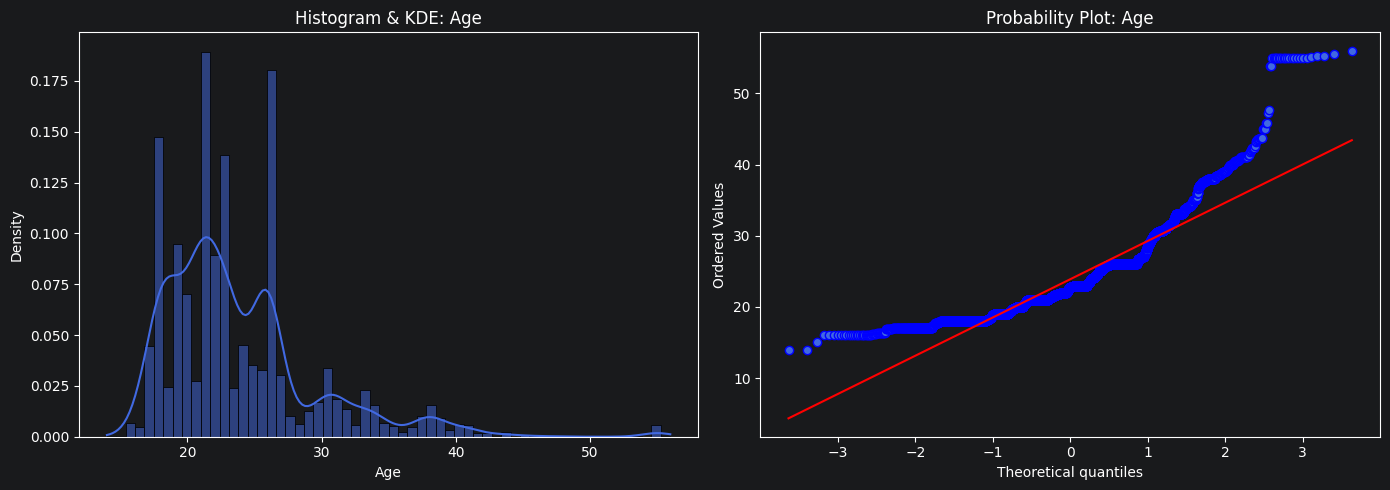

--- Normality Test Results: Age ---
K-S Statistic: 0.1611
P-value:       0.0000
Result: Reject the null hypothesis (Data does NOT look normal).


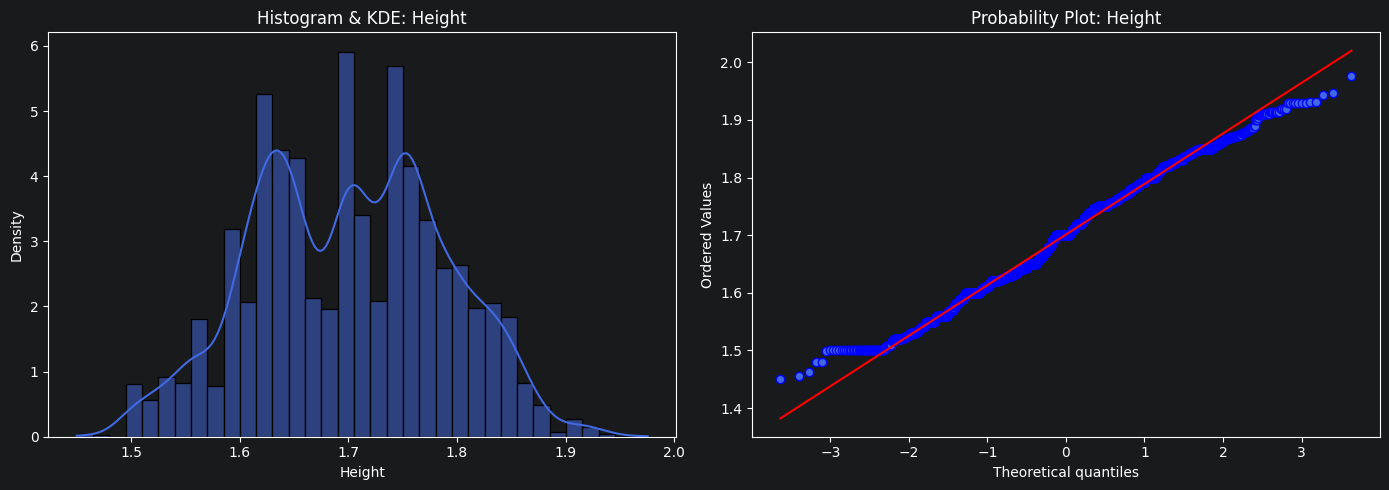

--- Normality Test Results: Height ---
K-S Statistic: 0.0721
P-value:       0.0000
Result: Reject the null hypothesis (Data does NOT look normal).


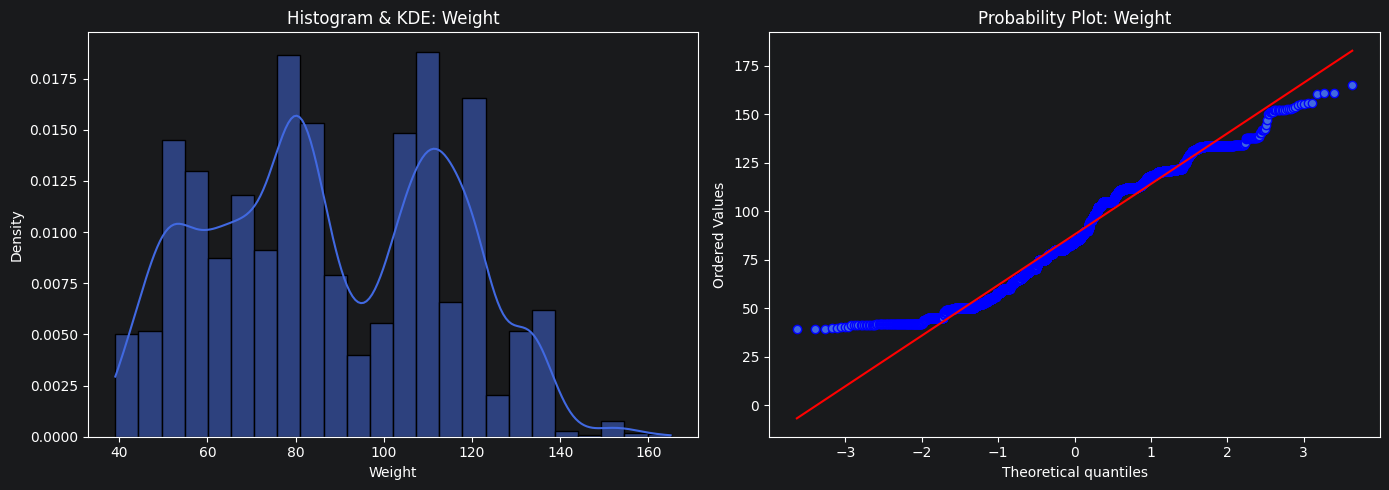

--- Normality Test Results: Weight ---
K-S Statistic: 0.0911
P-value:       0.0000
Result: Reject the null hypothesis (Data does NOT look normal).


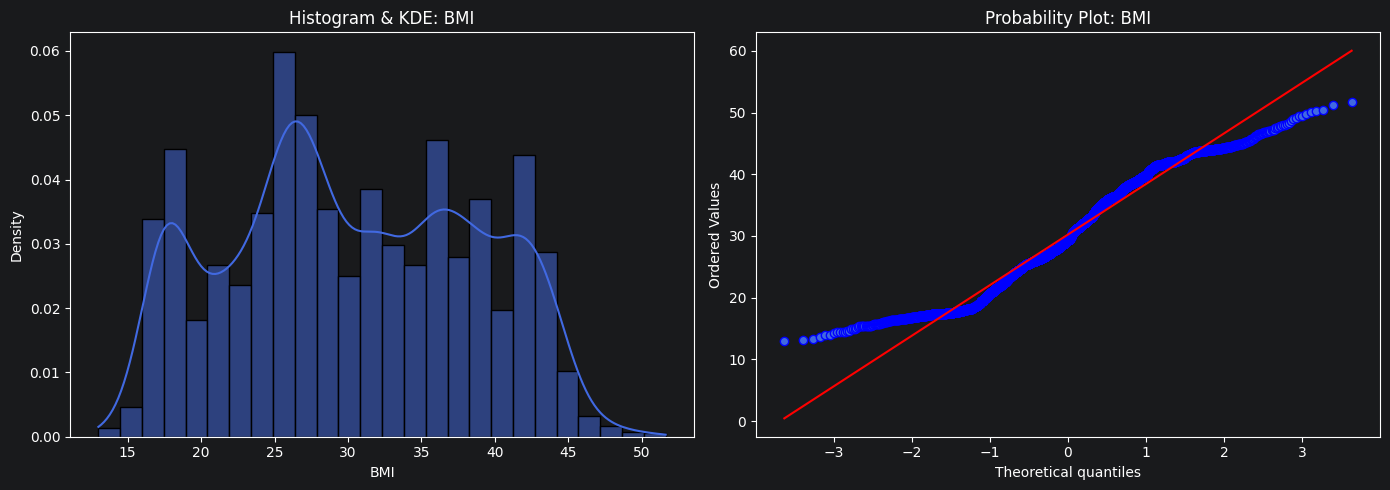

--- Normality Test Results: BMI ---
K-S Statistic: 0.0562
P-value:       0.0000
Result: Reject the null hypothesis (Data does NOT look normal).


In [49]:
num_feat_col = ['Age', 'Height', 'Weight', 'BMI']

for col in num_feat_col:
    check_normality(X_sample[col], label=col)

### Correlation

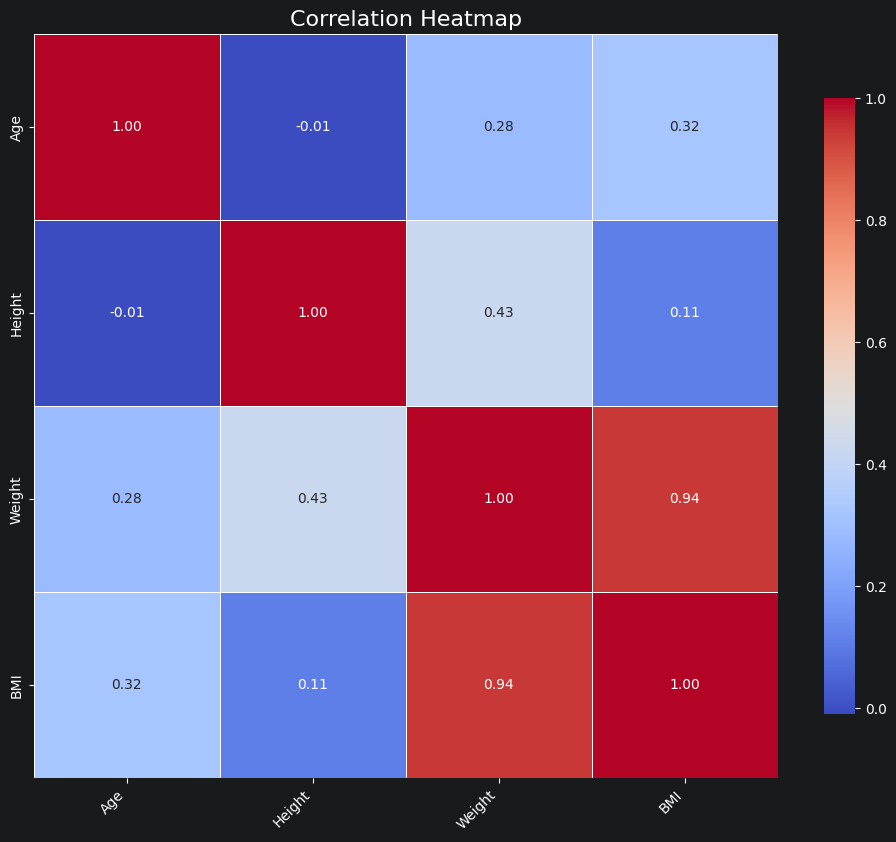

In [50]:
plot_correlation_heatmap(X_sample[num_feat_col], title="Correlation Heatmap")

### Target Correlation

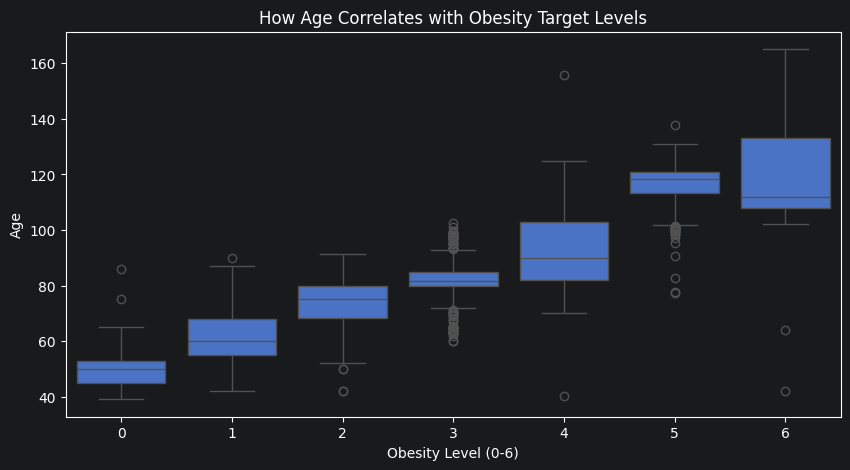

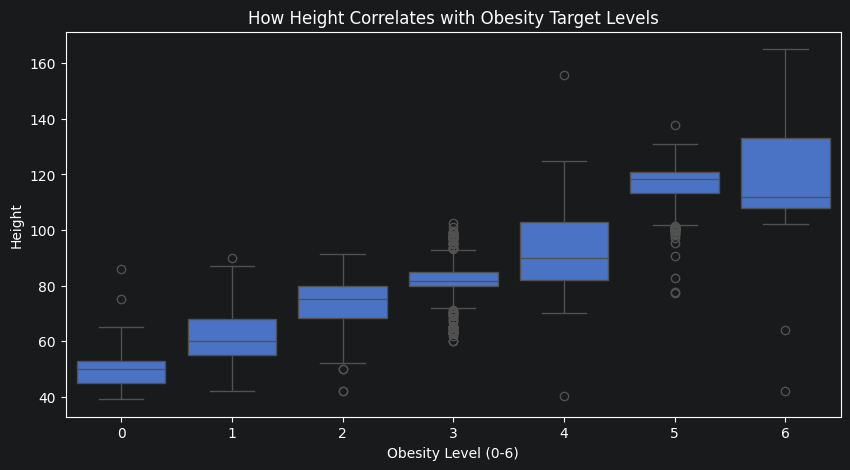

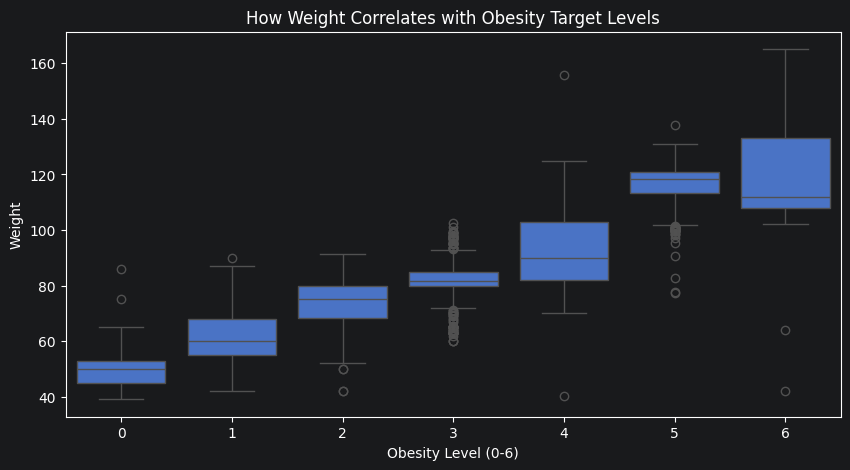

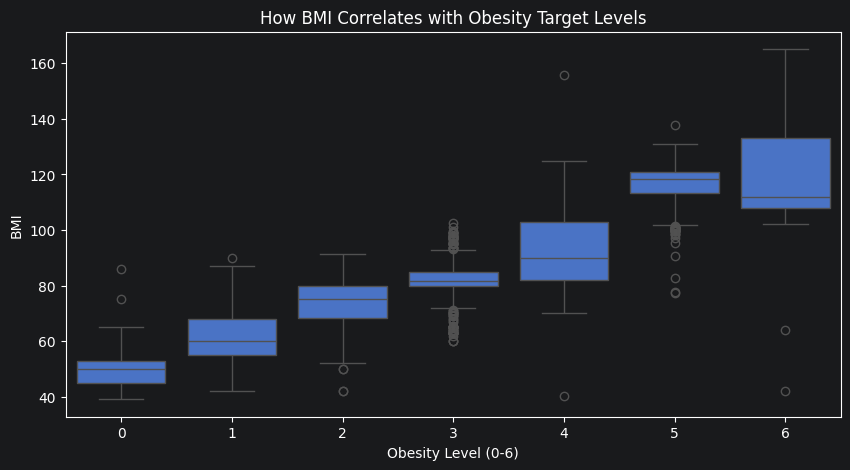

In [47]:
# Plotting 'Weight' across all 7 target classes

for col in num_feat_col:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=y_sample, y=X_sample['Weight'], legend=False)
    plt.xlabel("Obesity Level (0-6)")
    plt.ylabel(col)
    plt.title(f"How {col} Correlates with Obesity Target Levels")
    plt.show()

### BMI and Age
as two main factors

#### Correlation

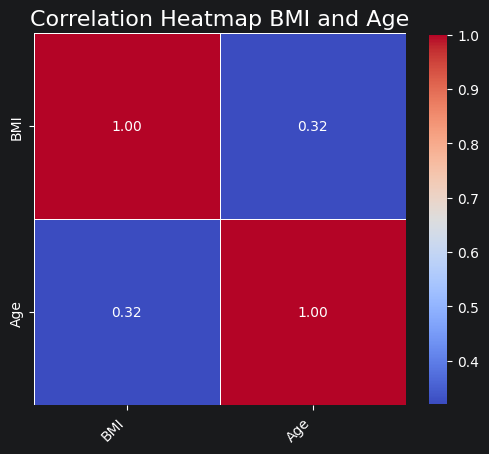

In [55]:
plot_correlation_heatmap(X_sample[['BMI', 'Age']], title="Correlation Heatmap BMI and Age", size=(6,6))

### ANOVA
F-classify score

In [59]:
from sklearn.feature_selection import f_classif
import pandas as pd

# Get only numeric columns from your sample
numeric_cols = num_feat_col

# Calculate ANOVA F-values
f_values, p_values = f_classif(X_sample[numeric_cols], y_sample)

# Put results into a clean DataFrame
corr_df = pd.DataFrame({
    'Feature': numeric_cols,
    'F-Score': f_values,
    'p-value': p_values
}).sort_values(by='F-Score', ascending=False)

print(corr_df)

  Feature       F-Score        p-value
3     BMI  11109.790851   0.000000e+00
2  Weight   5412.504962   0.000000e+00
0     Age    255.780115  4.485957e-286
1  Height    188.434785  5.295367e-217


## Numerical Summary
All features seems strongly correlated with target, more over weight and height could be easily replaced by BMI value.


## SMOTE-Affected Continuous Habits
(FCVC, NCP, CH2O, FAF, TUE)

## Ordinal Features
(CAEC, CALC)

## Demographic & Single Binary Features
(Gender_Male, family_history_with_overweight_yes, FAVC_yes, SMOKE_yes, SCC_yes)

## One-Hot Encoded Transportation Group
(Automobile, Bike, Motorbike, Public_Transportation, Walking)